In [1]:
import math
import warnings

import pandas as pd
import matplotlib.pyplot as plt

## Dataverwerking

In [2]:
# Keys to avoid typos
CATEGORY = 'category'
COUNTRY = 'country'
YEAR = 'year'
PERCENTAGE = 'percentage'

In [3]:
selected_year = str(2014)

In [4]:
# Defining paths
relative_root = "./../../assets/nato-defence-expenditure"

exp_per_capita_path = f"{relative_root}/spenditurepercapita2021usdollars.csv"
real_change_path = f"{relative_root}/realchange.csv"

exp_per_category_paths = {
    category: f"{relative_root}/portionofexpenditure_{category}.csv"
    for category in ['equipment', 'infrastructure', 'personel', 'other']
}

In [5]:
# Reading sources

exp_per_capita_raw = pd.read_csv(exp_per_capita_path)
real_change_raw = pd.read_csv(real_change_path)

exp_per_category_raw = {
    category: pd.read_csv(file)
    for category, file in exp_per_category_paths.items()
}

# Mapping and conversions

exp_per_capita_years = sorted([year for year in exp_per_capita_raw.columns if year.isdigit()])
exp_per_capita = exp_per_capita_raw.set_index(COUNTRY)[exp_per_capita_years]

real_change_years = sorted([year for year in real_change_raw.columns if year.isdigit()])
real_change = real_change_raw.set_index(COUNTRY)[real_change_years]

# Map expenditures to categories
exp_per_category = pd.concat(
    [df.assign(category=expense_category) for expense_category, df in exp_per_category_raw.items()],
    ignore_index=True
)

# Mapping expenditure year columns to rows
exp_per_category_years = sorted([year for year in exp_per_category.columns if year.isdigit()])
exp_per_category = exp_per_category.melt(
    id_vars=[COUNTRY, CATEGORY],
    value_vars=exp_per_category_years,
    var_name=YEAR,
    value_name=PERCENTAGE
)

# Show datasets individually, for exploration purposes

In [6]:
exp_per_capita

,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
country,,,,,,,,,,
Albania,67.922048,60.097647,59.056235,61.672794,67.288658,76.131215,75.392402,79.496148,82.058398,125.397324
Belgium,470.718397,448.480857,444.051684,443.362327,452.664449,458.599590,492.274131,540.421754,624.588182,636.089346
Bulgaria,126.356871,125.223741,129.671124,131.877018,161.732580,366.386120,179.694418,186.565837,216.325248,270.156541
Canada,520.440037,619.960849,598.267706,755.089189,691.148825,692.073464,707.049291,667.223856,642.492722,700.712666
Croatia,248.052658,248.437991,236.122412,254.742604,250.785837,271.555446,265.771195,350.989478,346.349045,331.177908
Czechia,218.207087,247.842558,234.683983,266.513302,292.224771,320.696727,332.990530,372.226724,356.608817,364.313195
Denmark,704.107051,692.970615,731.430097,741.081058,844.929012,866.420973,897.224980,903.149062,961.349678,1432.844555
Estonia,430.632559,461.350808,484.049908,496.004368,512.442181,536.643342,590.360073,562.941955,588.528803,787.608338
Finland,720.538850,720.661349,723.837035,725.552506,734.407278,777.772482,799.101423,749.070788,907.239447,1124.693844


In [7]:
real_change

,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
country,,,,,,,,,,
Albania,-2.736762,-11.764690,-1.903411,4.321690,8.840068,12.667505,-1.525623,4.477177,1.975039,51.274486
Belgium,-2.114723,-4.246982,-0.335560,0.206674,2.520796,1.817757,7.961328,10.095074,16.204344,2.937128
Bulgaria,-9.084088,-1.557274,2.798868,0.956502,21.769162,124.952460,-51.194804,2.653169,9.321987,24.826320
Canada,4.952269,20.088503,-2.479358,27.756425,-7.176230,1.611073,3.369036,-5.078808,-2.081569,12.156692
Croatia,25.940092,-1.036415,-5.987292,6.152083,-2.820064,7.196007,-2.997466,30.883574,-1.907197,-4.281112
Czechia,-5.025732,13.862279,-4.940836,13.895406,10.060723,10.196569,3.911143,9.850641,-1.362763,2.377458
Denmark,-4.823221,-1.004457,6.426419,2.065113,14.647653,2.987092,3.858527,0.954141,7.045670,50.567778
Estonia,3.782595,7.133285,4.999926,2.547539,3.706279,5.118787,10.258467,-4.572608,5.959036,35.909934
Finland,-6.046223,0.402317,0.715993,0.529286,1.404355,6.000840,2.872647,-6.108164,21.421715,24.326315


In [8]:
exp_per_category

,country,category,year,percentage
0,Albania,equipment,2014,16.649791
1,Belgium,equipment,2014,3.515492
2,Bulgaria,equipment,2014,1.027558
3,Canada,equipment,2014,13.029572
4,Croatia,equipment,2014,5.558603
...,...,...,...,...
1235,Spain,other,2023,21.848771
1236,Sweden,other,2023,50.072478
1237,Türkiye,other,2023,16.536811
1238,United Kingdom,other,2023,35.843434


## Visualisaties

In [9]:
# Voor subfiguren
subfig_n_cols = 4

# Voor plots
pie_start_angle = 90

Hoe veel geeft elk individueel land uit aan elke categorie?

Categorieën:
- Equipment
- Infrastructure
- Personnel
- Other

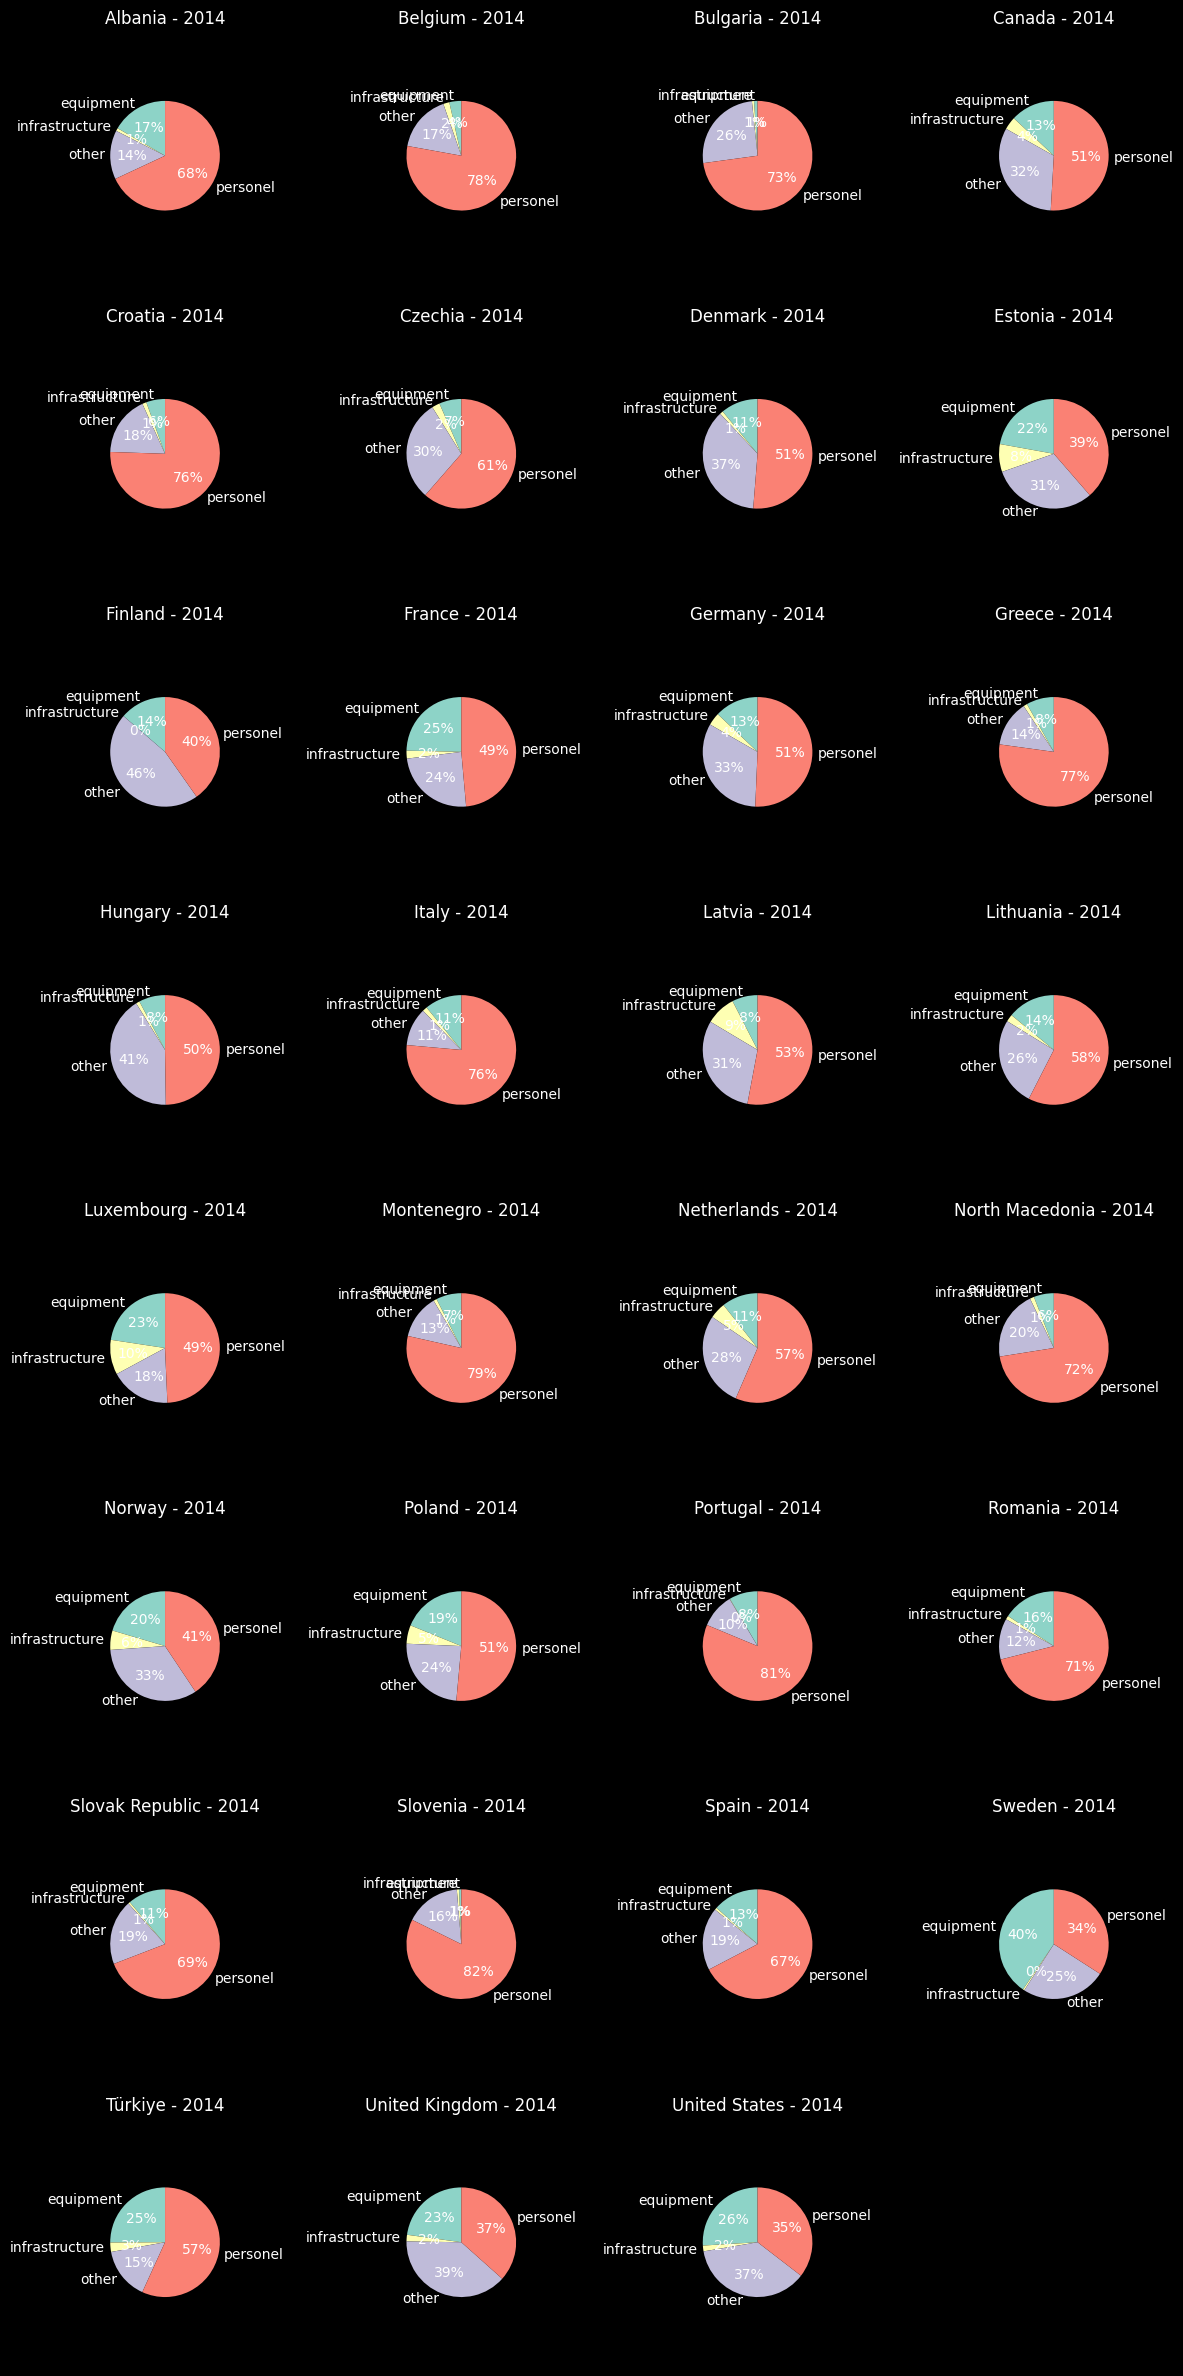

In [10]:
selected_year_exp_per_category = (exp_per_category[exp_per_category[YEAR] == selected_year]
                                  .copy()
                                  .pivot(index=COUNTRY, columns=CATEGORY, values=PERCENTAGE)
                                  )

# Determine subfigure sizes
n_subfigs = len(selected_year_exp_per_category)
subfig_n_rows = math.ceil(n_subfigs / subfig_n_cols)

fig, axes = plt.subplots(subfig_n_rows, subfig_n_cols, figsize=(subfig_n_cols * 3, subfig_n_rows * 3))
axes = axes.flatten() if hasattr(axes, 'flatten') else [axes]

for index, (country, row) in enumerate(selected_year_exp_per_category.iterrows()):
    axis = axes[index]
    categories, percentages = row.index, row.values
    axis.pie(percentages, labels=categories, autopct='%1.0f%%', startangle=pie_start_angle)
    axis.set_title(f"{country} - {selected_year}")
    axis.margins(0)
    axis.axis('equal')

# Hide any unused subplots
for axis in axes[n_subfigs:]:
    axis.axis('off')

plt.tight_layout()
plt.show()

Hoe veel geeft elk land uit doorheen de tijd?

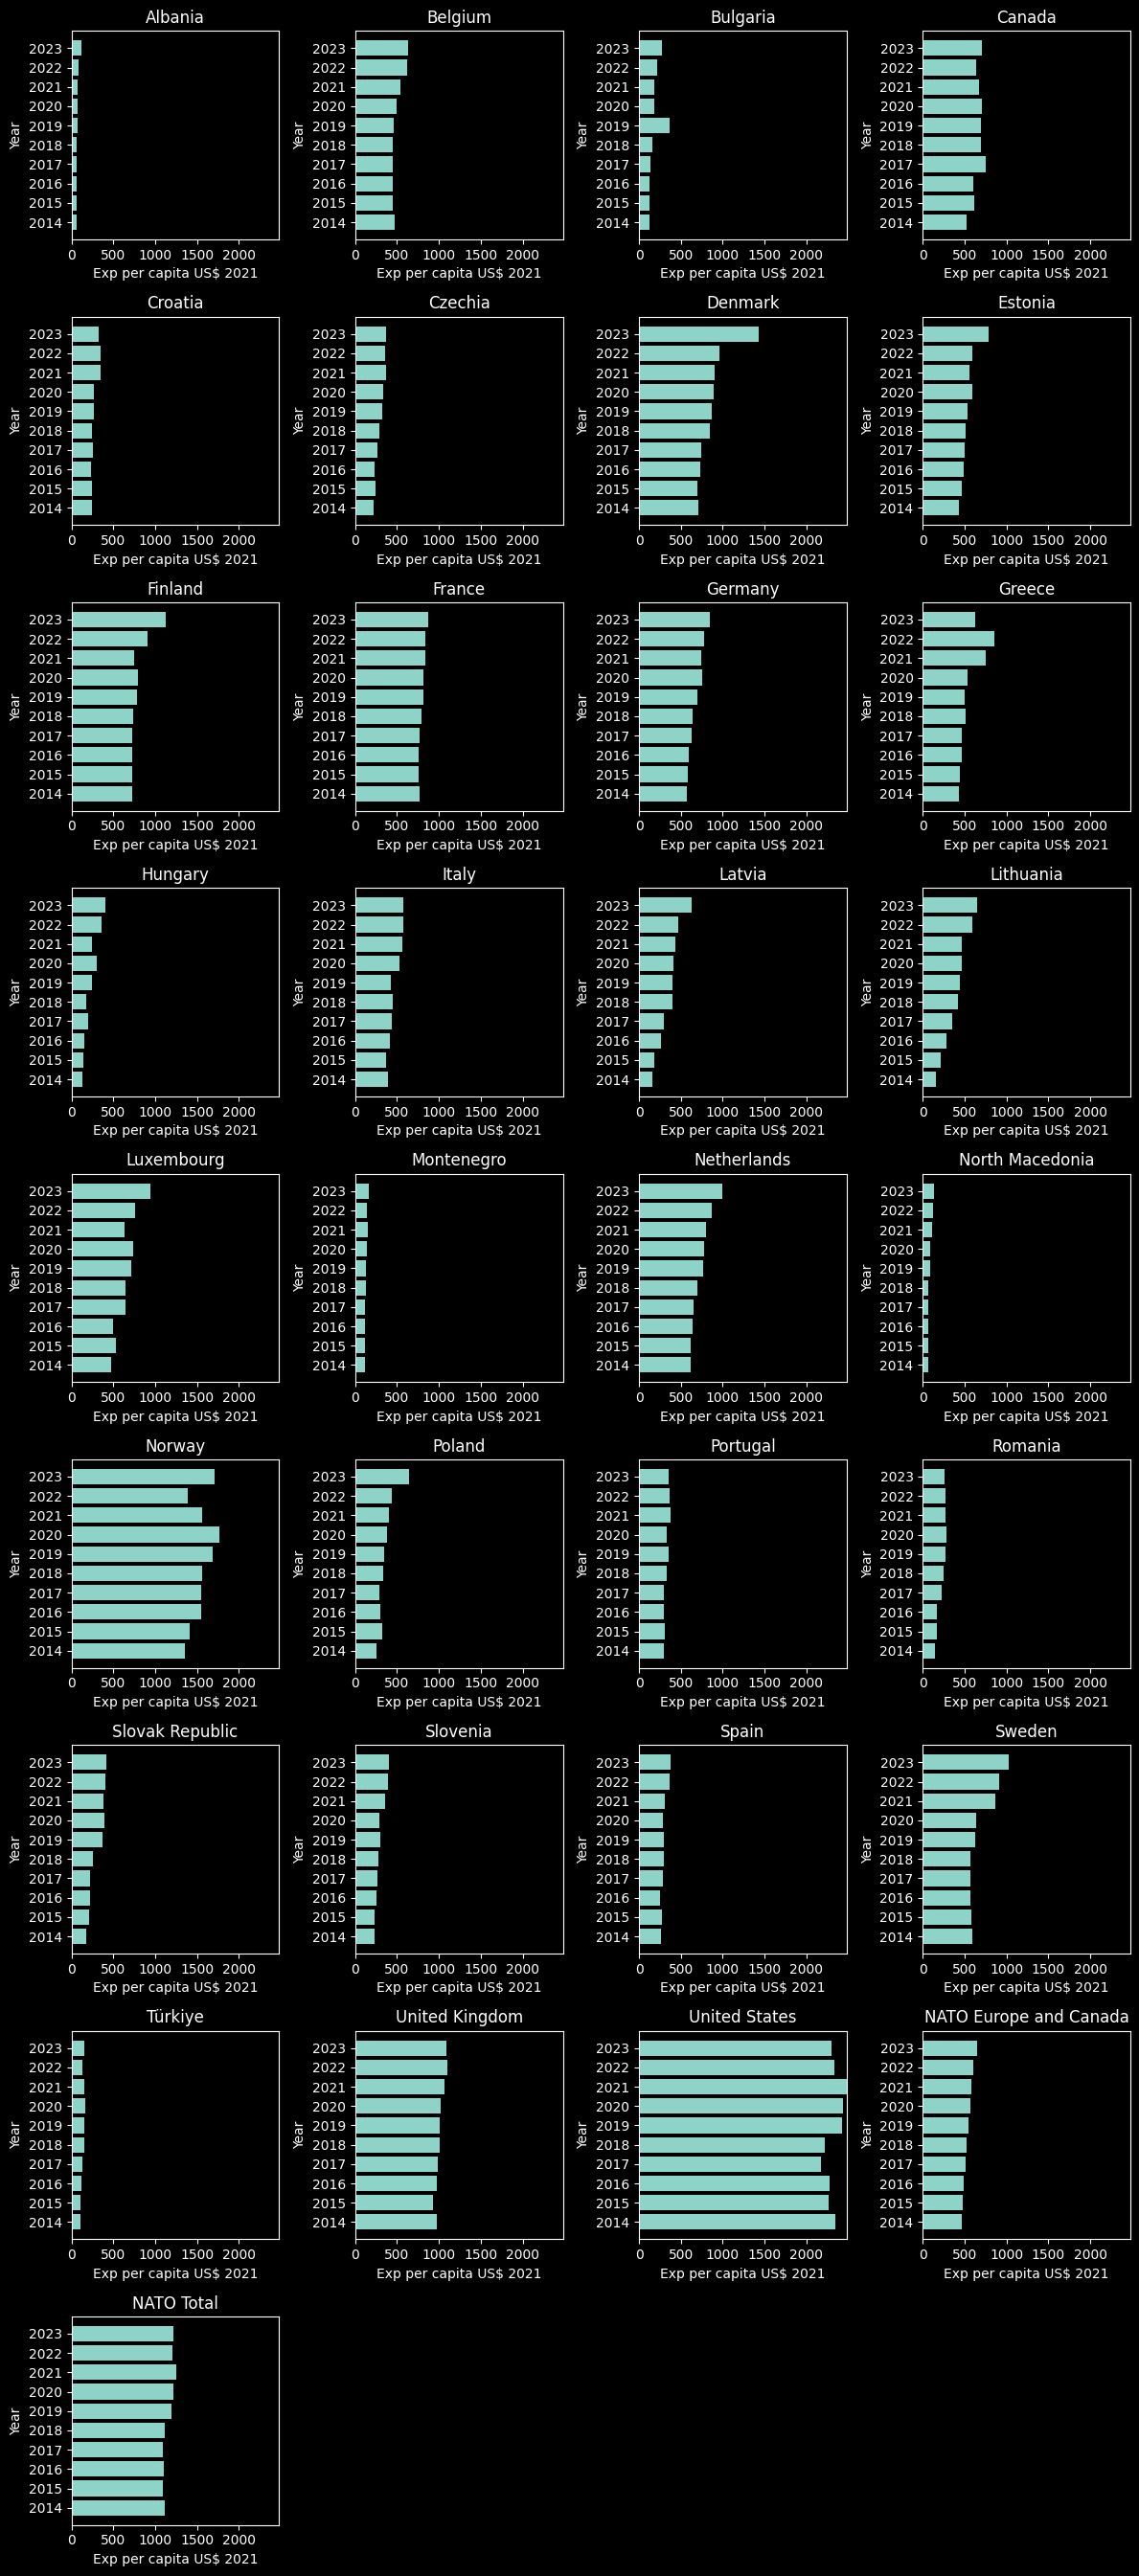

In [11]:
# Determine fixed max y
exp_per_capita_maxy = max(exp_per_capita.max())

# Plots
n_subfigs = len(exp_per_capita)
subfig_n_rows = math.ceil(n_subfigs / subfig_n_cols)

fig, axes = plt.subplots(subfig_n_rows, subfig_n_cols, figsize=(subfig_n_cols * 3, subfig_n_rows * 3))
axes = axes.flatten() if hasattr(axes, 'flatten') else [axes]

for index, (country, row) in enumerate(exp_per_capita.iterrows()):
    axis = axes[index]
    exps = row[exp_per_capita_years]

    axis.barh(exp_per_capita_years, exps)
    axis.set_title(country)
    axis.set_ylabel("Year")
    axis.set_xlabel("Exp per capita US$ 2021")
    axis.set_xlim([0, exp_per_capita_maxy])

# Hide any unused subplots
for axis in axes[n_subfigs:]:
    axis.axis('off')

plt.tight_layout()
plt.show()

Hoe veel verandert de uitgave doorheen de jaren per land?

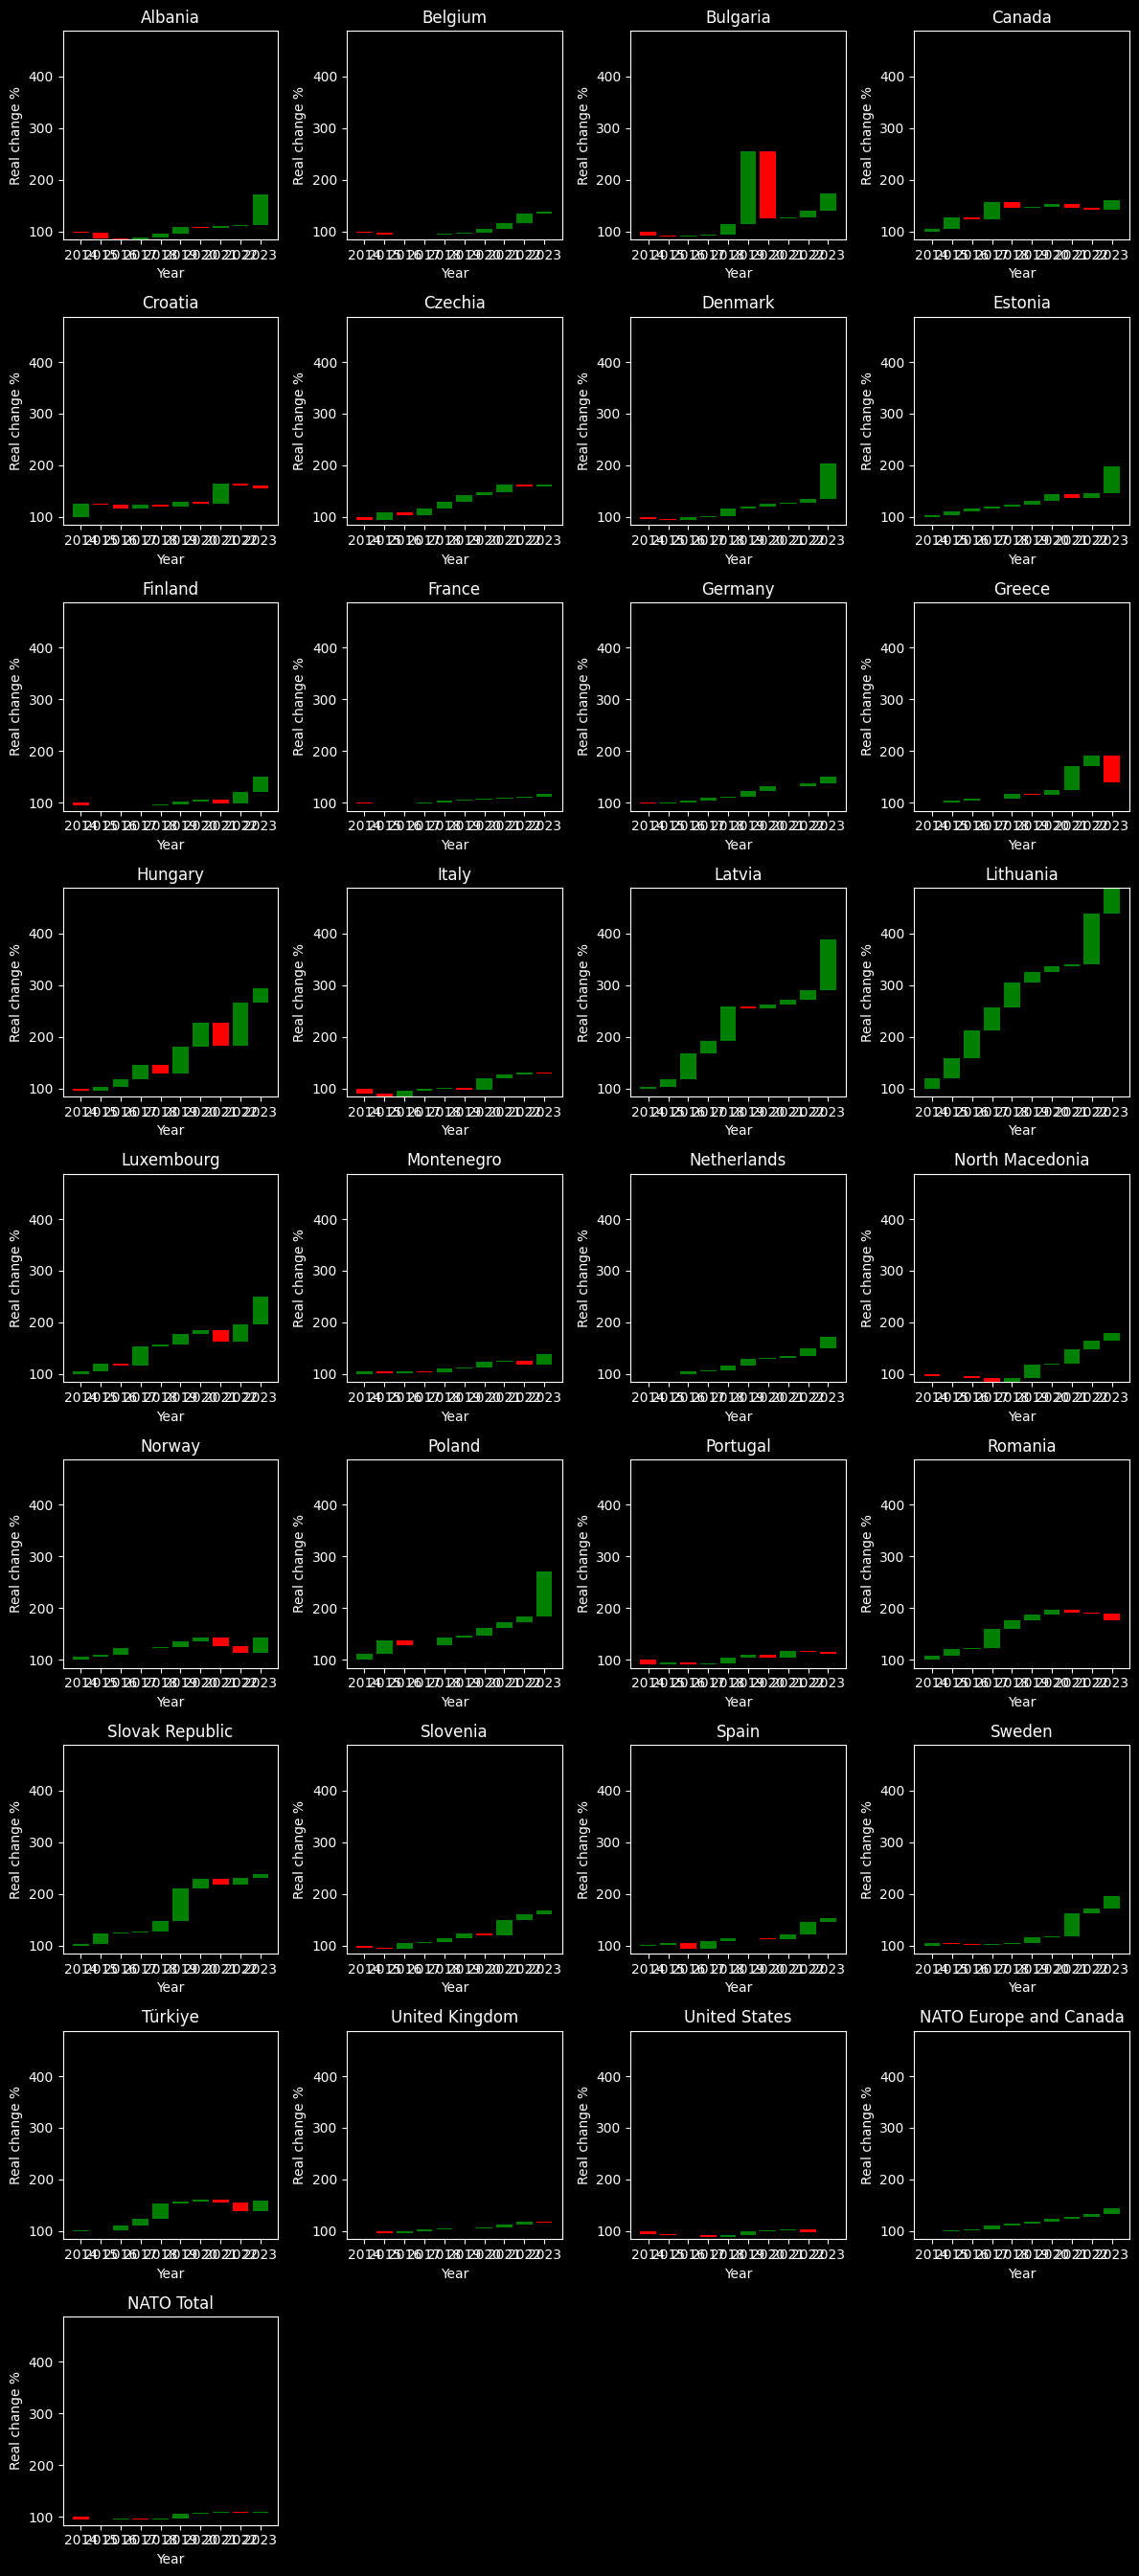

In [12]:
# Determine fixed y-range for all subplots
global_min = float("inf")
global_max = float("-inf")

for _, row in real_change.iterrows():
    start = 100.0
    country_min = start
    country_max = start

    for change in row[real_change_years]:
        end = start * (1 + change / 100.0)
        low, high = sorted((start, end))
        country_min = min(country_min, low)
        country_max = max(country_max, high)
        start = end

    global_min = min(global_min, country_min)
    global_max = max(global_max, country_max)

# Plots
n_subfigs = len(real_change)
subfig_n_rows = math.ceil(n_subfigs / subfig_n_cols)

fig, axes = plt.subplots(subfig_n_rows, subfig_n_cols, figsize=(subfig_n_cols * 3, subfig_n_rows * 3))
axes = axes.flatten() if hasattr(axes, 'flatten') else [axes]

for index, (country, row) in enumerate(real_change.iterrows()):
    axis = axes[index]

    start = 100
    starts, heights, colors = [], [], []

    for change in row[real_change_years]:
        end = start * (1 + change / 100.0)
        starts.append(start)
        heights.append(end - start)
        colors.append('green' if change > 0 else 'red')
        start = end

    axis.bar(real_change_years, heights, bottom=starts, color=colors)
    axis.set_title(country)
    axis.set_xlabel("Year")
    axis.set_ylabel("Real change %")
    axis.axhline(y=0, color='black', linewidth=0.5)
    axis.set_ylim(global_min, global_max)
    axis.tick_params(axis='both')

# Hide any unused subplots
for axis in axes[n_subfigs:]:
    axis.axis('off')

plt.tight_layout()
plt.show()